# Table of Contents

- [0. Preperations](#0-preperations)

- [1. Embeddings](#1-embeddings)
  - [1.1. Loading the ISCO Data & Creating Embeddings](#11-loading-the-isco-data--creating-embeddings)
  - [1.2. Loading and Splitting Job Ad Data & Creating Embeddings](#12-loading-and-splitting-job-ad-data--creating-embeddings)
  - [1.3. Checking for Token Limit Violations](#13-checking-for-token-limit-violations)
  - [1.4. Evaluating Retrieval & Embedding Correctness](#14-evaluating-retrieval--embedding-correctness)
  - [1.5. Selecting Candidate Pool Sizes ($k$) for Downstream Inference](#15-selecting-candidate-pool-sizes-k-for-downstream-inference)
- [2. Prompt Template Engineering](#2-prompt-template-engineering)
  - [2.1. Prompt Construction Function](#21-prompt-construction-function)
  - [2.2. Defining the System Prompt](#22-defining-the-system-prompt)
  - [2.3. Batch Prompt Generation](#23-batch-prompt-generation)
- [3. Decoder LLM Inference & Post-Processing](#3-decoder-llm-inference--post-processing)
  - [3.1. Emptying GPU storage](#31-emptying-gpu-storage)
  - [3.2. Loading Tokenizer & LLM](#32-loading-tokenizer-llm)
  - [3.3. Defining Function for running Decoder over data](#33-defining-function-for-running-decoder-over-data)
  - [3.4. Executing In-Context LLM](#34-executing-in-context-llm)
  - [3.5. Output Parsing & ISCO Code Mapping](#35-output-parsing--isco-code-mapping)
- [4. Evaluation](#4-evaluation)
  - [4.1. Performance Report (Levels 1–3)](#41-multi-level-performance-report-levels-13)
  - [4.2. Confusion Matrices](#42-confusion-matrices)
  - [4.3. Detailed Level 1 Major Group Classification Report](#43-detailed-level-1-major-group-classification-report)

# 0. Preperations

In [ ]:
# Necessary for succesfully running on remote GPU

%pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
%pip install --upgrade typing-extensions
%pip install sentence-transformers
%pip install accelerate

In [ ]:
import pandas as pd
import numpy as np
import platform
import os
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig, pipeline
from transformers import logging as hf_logging
import random
import torch
import gc
import warnings
from tqdm import tqdm
import regex as re
import seaborn as sns
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Download Access-Token for HuggingFace
os.environ["HF_TOKEN"] = "XXX"

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    device = "cuda"
    dev_map = "auto"
    model_dtype = torch.bfloat16
    print(f"System: {platform.system()} (NVIDIA CUDA) -> device_map='auto'")

elif torch.mps.is_available():
    device = "mps"
    dev_map = None
    model_dtype = torch.float16
    print(f"System: {platform.system()} (Apple Silicon) -> device='mps'")

else:
    device = "cpu"
    dev_map = None
    model_dtype = torch.float32
    print(f"System: {platform.system()} (CPU) -> device='cpu'")

System: Linux (NVIDIA CUDA) -> device_map='auto'


# 1. Embeddings

### 1.1. Loading the Embedding LLM

In [3]:
embed_model_id = "BAAI/bge-en-icl"

embed_model = SentenceTransformer(
    embed_model_id,
    device=device,
    model_kwargs={"torch_dtype": model_dtype}
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

### 1.1. Loading the isco data & Creating the Embeddings

In [ ]:
isco_path = "../data/isco_with_embeddings.parquet"

# if script was already run before and embedding vectors exist already
if os.path.exists(isco_path):
    isco_df = pd.read_parquet(isco_path)
    isco_embeddings = np.vstack(isco_df["embedding_vectors"].values)

else:
    # Loading raw ISCO data (making sure correct data types are used by dtype)
    isco_df = pd.read_csv("../data/raw/ISCO/isco_level3.csv", dtype={"isco_code": str, "major_code": str, "submajor_code": str})

    # Filling empty task cells
    isco_df["tasks"] = isco_df["tasks"].fillna("Tasks not specified.")

    # Putting different columns together for the final embedding text
    isco_df["embedding_texts"] = (
        "Title: " + isco_df["title"] + "\n" +
        "Category: " + isco_df["submajor_code"] + "\n" +
        "Definition: " + isco_df["definition"] + " " + 
        "Tasks: " + isco_df["tasks"]
    )
    embedding_texts = isco_df["embedding_texts"].tolist()

    # Creating the embedding vectors
    # normalizing emebdding vectors for simplifying the similarity calculations later on (turned into pure skalar product)
        # cosine similarity = angle between the vektors:
        #   --> cos(0) = 1 --> no difference in vektors
        #   --> cos(90) = 0 --> independence
        #   --> cos(180) = -1 --> opposite 
    isco_embeddings = embed_model.encode(embedding_texts, normalize_embeddings=True, show_progress_bar=True)

    isco_df["embedding_vectors"] = isco_embeddings.tolist()
    isco_df["isco_code"] = isco_df["isco_code"].astype(str)

    # 5. Saving ISCO Data with embedding vectors
    isco_df.to_parquet(isco_path)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

### 1.2. Loading and Splitting Job Ad Data & Creating Embeddings

In [ ]:
ads_path = "../data/job_ads_with_embeddings.parquet"

# If script was already run before and embedding vectors exist already
if os.path.exists(ads_path):
    ads_df = pd.read_parquet(ads_path)
    ads_embeddings = ads_df["embeddings"].tolist()
    
else:
    # 1. Loading raw Job Ad data (Using same splitting technique as in Two-Step Model)
    df_labeled = pd.read_csv("../data/labeled.csv")
    counts = df_labeled["isco"].value_counts()

    n1_classes = counts[counts == 1].index
    n2_classes = counts[counts == 2].index
    common_classes = counts[counts >= 3].index

    df_n1 = df_labeled[df_labeled["isco"].isin(n1_classes)]
    df_n2 = df_labeled[df_labeled["isco"].isin(n2_classes)]
    df_common = df_labeled[df_labeled["isco"].isin(common_classes)]

    train_c, _ = train_test_split(df_common, test_size=0.15, random_state=SEED, stratify=df_common["isco"])
    _, ads_df = train_test_split(train_c, test_size=0.1765, random_state=SEED, stratify=train_c["isco"])

    print(f"Validation Set Size: N = {len(ads_df)}")

    # 2. Adding BGE specific Instruction text, so that it nows it needs to fit the job ad to the isco embeddings
    instruction = "Represent this sentence for searching relevant passages: "
    ads_embedding_texts = [instruction + text for text in ads_df["text_final"].tolist()]

    # same as above
    ads_embeddings = embed_model.encode(ads_embedding_texts, normalize_embeddings=True, show_progress_bar=True).tolist()

    ads_df["embeddings"] = ads_embeddings
    ads_df["isco"] = ads_df["isco"].astype(str)
    ads_df.to_parquet(ads_path)

ads_embeddings = ads_df["embeddings"].tolist()


Validation Set Size: N = 104


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

### 1.3. Checking for token limit vialations

In [6]:
# Loading embedding tokenizer
emb_tokenizer = embed_model.tokenizer
max_model_len = embed_model.max_seq_length

# measuring token length for each job ad
token_lengths = [
    len(emb_tokenizer.encode(text, truncation=False)) 
    for text in ads_embedding_texts
]

lengths_series = pd.Series(token_lengths)

# Counting token limit vialations
exceeding_count = (lengths_series > max_model_len).sum()
pct_exceeding = (exceeding_count / len(lengths_series)) * 100

print(f"Model-limit:                   {max_model_len} Tokens")
print(f"Vialations:                    {exceeding_count} von {len(lengths_series)} ({pct_exceeding:.2f}%)")
print(f"Longest Ad token length:       {lengths_series.max()} Tokens")
print(f"Shortest Ad token length:      {lengths_series.min()} Tokens")
print(f"Median Ad token length:        {lengths_series.median():.1f} Tokens")
print(f"Mean Ad token length:          {lengths_series.mean():.1f} Tokens")

Model-limit:                   32768 Tokens
Vialations:                    0 von 104 (0.00%)
Longest Ad token length:       1990 Tokens
Shortest Ad token length:      17 Tokens
Median Ad token length:        662.5 Tokens
Mean Ad token length:          755.4 Tokens


### 1.4. Checking correctness of embeddings

In [7]:
# Preparing Embedding Vectors and calculating Cosine Similarity Matrix
ads_vektors = np.array(ads_embeddings)
isco_vektors = np.array(isco_embeddings)

# Scalar product of normalized embedding vectors (Values between -1 and 1)
sim_mat = ads_vektors @ isco_vektors.T

# Sorting indices once for all job ads in descending order of similarity
sorted_indices = np.argsort(sim_mat, axis=1)[:, ::-1]

# Setup candidate DataFrame and parameters
all_isco_codes = isco_df["isco_code"].astype(str).values
gold_labels = ads_df["isco"].astype(str).values
n_ads = len(ads_df)

# List of k-values to evaluate and compare
k_values = [1, 3, 5, 6, 8, 10, 15, 20]

# Initializing separate DataFrame to store candidate pools
candidate_df = pd.DataFrame(index=ads_df.index)

# List to collect evaluation metrics for the summary table
comparison_results = []

# Iterating through different values of k
for k in k_values:
    top_k_indices = sorted_indices[:, :k]

    reciprocal_ranks = []
    retrieval_hits = []
    raw_top_k_list = []
    shuffled_top_k_list = []
    oracle_top_k_list = []

    for i in range(n_ads):
        gold_code = gold_labels[i]
        retrieved_ranked = all_isco_codes[top_k_indices[i]].tolist()
        raw_top_k_list.append(retrieved_ranked)

        # Calculating Recall@k and MRR@k
        if gold_code in retrieved_ranked:
            rank = retrieved_ranked.index(gold_code) + 1
            reciprocal_ranks.append(1.0 / rank)
            retrieval_hits.append(True)
        else:
            reciprocal_ranks.append(0.0)
            retrieval_hits.append(False)

        # Setting deterministic local random generator per job ad and k
        rng = random.Random(SEED + k * 1000 + i)

        # Shuffling candidates so top embedding match is not always at position 0
        shuffled_candidates = rng.sample(retrieved_ranked, len(retrieved_ranked))
        shuffled_top_k_list.append(shuffled_candidates)

        # Creating Oracle candidates (guaranteeing presence of gold label)
        oracle_candidates = list(shuffled_candidates)
        if gold_code not in oracle_candidates:
            rand_idx = rng.randint(0, k - 1)
            oracle_candidates[rand_idx] = gold_code
        oracle_top_k_list.append(oracle_candidates)

    # Calculating aggregate metrics
    hits_count = sum(retrieval_hits)
    recall_k = hits_count / n_ads
    mrr_k = np.mean(reciprocal_ranks)

    # Storing candidate pools in candidate_df
    candidate_df[f"top_{k}_isco"] = shuffled_top_k_list
    candidate_df[f"oracle_top_{k}_isco"] = oracle_top_k_list

    # Collecting metrics for comparison table
    comparison_results.append({
        "k": k,
        "Recall@k (%)": round(recall_k * 100, 2),
        "Hits": f"{hits_count}/{n_ads}",
        "MRR@k (%)": round(mrr_k * 100, 2),
    })

# Creating formatted comparison results DataFrame
results_df = pd.DataFrame(comparison_results)

# Printing comparison table to terminal / notebook output
print("=" * 50)
print("     RETRIEVAL PERFORMANCE COMPARISON ACROSS k    ")
print("=" * 50)
print(results_df.to_string(index=False))
print("=" * 50)

     RETRIEVAL PERFORMANCE COMPARISON ACROSS k    
 k  Recall@k (%)   Hits  MRR@k (%)
 1         42.31 44/104      42.31
 3         69.23 72/104      54.33
 5         78.85 82/104      56.49
 6         81.73 85/104      56.97
 8         83.65 87/104      57.23
10         87.50 91/104      57.65
15         91.35 95/104      57.93
20         94.23 98/104      58.08


### 1.5. Selecting best k values for the decoder LLLM

In [8]:
# Selecting the top 3 chosen k-values for downstream Decoder LLM evaluation
selected_k_values = [5, 10, 15]

# Assigning the selected candidate sets (standard and oracle) to the main DataFrame
for k in selected_k_values:
    ads_df[f"top_{k}_isco"] = candidate_df[f"top_{k}_isco"]
    ads_df[f"oracle_top_{k}_isco"] = candidate_df[f"oracle_top_{k}_isco"]

# Just for checking: Listing all candidate columns now available in ads_df
candidate_cols = [col for col in ads_df.columns if "top_" in col and "_isco" in col]
print(f"\ncandidate columns in ads_df:\n{candidate_cols}")


candidate columns in ads_df:
['top_5_isco', 'oracle_top_5_isco', 'top_10_isco', 'oracle_top_10_isco', 'top_15_isco', 'oracle_top_15_isco']


# 2. Building Prompt-Template

### 2.1. Function for creating prompts

In [9]:
def build_prompt(df_row, isco_df = isco_df, candidate_col = "top_k_isco"):
    """
    This function takes in a row of the dataframe carrying columns with job ads and with their top k similar isco classes , as well es a
    corresponding isco class dataframe. On this basis it produces a prompt for a decoder llm including the job ad itself,
    information about the k most similar isco classes, as well as instructions on what to do with those informations

    input:
        - df_row: pd.series -->     row of the job ad dataframe (one job ad)
        - isco_df: pd.DataFrame --> dataframe carrying the informations about each isco class
        - candidate_col: str -->    name of the column that carries the list with the isco codes of the top k similar isco classes of the job ad
                                    Could also be 'oracle_top_k_isco' if 'top_k_isco' didn't get the gold_label in 100% of cases 

    output:
        - user_prompt: docstring -->    finished user prompt for the decoder llm 
    """

    # Loading the job ad text
    description = df_row["text_final"]
    # Loading the top k similar isco classes
    selection_isco = df_row[candidate_col]

    # Generating small df with only the pre-selected ISCO codes
    selection_df = (
        isco_df.set_index("isco_code").loc[selection_isco].reset_index()
    )

    # Formatting the selection-ISCO texts and saving them into a list:
    selection_texts = []
    options = [x for x in range(1,len(selection_isco)+1)]
    for idx, row in selection_df.iterrows():
        candidate_text = (

            f"Candidate {options[idx]}:\n"
            f"- Title: {row['title']}\n"
            f"- Definition: {row['definition']}\n"
            f"- Tasks: {row['tasks']}\n"
        )
        selection_texts.append(candidate_text)

    # Glueing all candidate texts into one big text
    selection_prompt = "\n".join(selection_texts)

    # Bulding final big prompt out of the pieces
    user_prompt = f"""Job Advertisement:
    '''
    {description}
    '''

    Candidate Options:
    {selection_prompt}

    Instructions:
    - Select the single best matching candidate for the job advertisement.
    - Output strictly 2 sentences: 1 sentence of brief reasoning, followed immediately by the final decision.
    - Do NOT create headings, lists, or candidate-by-candidate breakdowns.
    - You must ALWAYS end your output on "Therefore I chose Candidate: " followed by the number of the candidate you chose. 
    - You MUST choose one of the given Candidates even if no ones fully matches the candidates, you MUST pick the best matching one. You cannot choose no candidate!
    """

    return user_prompt

### 2.2. Defining the system prompt

In [10]:
sys_p = f"""
You are an expert for labor market analysis and a professional headhunter.
Your goal is to analyze the following job ad and choose the single most matching Job-Class definition from the candidate selection.
"""

### 2.3. Generating prompts

In [11]:
# Iterating over the selected k-values to generate both standard and oracle prompts
for k in selected_k_values:
    # Generating standard prompts for current k
    tqdm.pandas(desc=f"Prompt Generation (k={k})")
    ads_df[f"prompt_k{k}"] = ads_df.progress_apply(
        lambda x: build_prompt(x, isco_df=isco_df, candidate_col=f"top_{k}_isco"),
        axis=1
    )
    
    # Generating oracle prompts for current k
    tqdm.pandas(desc=f"Oracle Prompt Generation (k={k})")
    ads_df[f"oracle_prompt_k{k}"] = ads_df.progress_apply(
        lambda x: build_prompt(x, isco_df=isco_df, candidate_col=f"oracle_top_{k}_isco"),
        axis=1
    )

# Just for checking: listing all generated prompt columns
prompt_cols = [col for col in ads_df.columns if "prompt_k" in col]
print(f"\nSuccessfully generated {len(prompt_cols)} prompt columns:\n{prompt_cols}")

Oracle Prompt Generation (k=15): 100%|██████████| 104/104 [00:00<00:00, 1101.21it/s]


Successfully generated 6 prompt columns:
['prompt_k5', 'oracle_prompt_k5', 'prompt_k10', 'oracle_prompt_k10', 'prompt_k15', 'oracle_prompt_k15']


# 3. Decoder LLM

### 3.1. Emptying GPU storage

In [12]:
# Emptying GPU storage for the decoder LLM
if "embed_model" in locals() or "embed_model" in globals():
    del embed_model

# Forcing garbage collection to release unreferenced Python objects/tensors
gc.collect()

# Freeing GPU VRAM and CPU memory from previous model
if device == "cuda":
    torch.cuda.empty_cache()
elif device == "mps":
    torch.mps.empty_cache()

### 3.2. Loading Tokenizer & LLM

In [13]:
dec_model_id = "meta-llama/Llama-3.1-8B-Instruct"

# Loading Tokenizer
dec_tokenizer = AutoTokenizer.from_pretrained(
    dec_model_id,
    token=os.environ.get("HF_TOKEN")
)

# Making sure Pad token is defined
if dec_tokenizer.pad_token is None:
    dec_tokenizer.pad_token = dec_tokenizer.eos_token

# Loading Model
if dev_map is not None:
    # NVIDIA CUDA / Remote Server
    dec_model = AutoModelForCausalLM.from_pretrained(
        dec_model_id,
        dtype=model_dtype,
        device_map=dev_map,
        token=os.environ.get("HF_TOKEN")
    )
else:
    # Apple-MPS (laptop for local testing) or CPU
    dec_model = AutoModelForCausalLM.from_pretrained(
        dec_model_id,
        dtype=model_dtype,
        token=os.environ.get("HF_TOKEN")
    ).to(device)


# Defining Generation Configuration explicitly
gen_config = GenerationConfig.from_pretrained(
    dec_model_id,
    max_new_tokens=200,
    do_sample=False,
    pad_token_id=dec_tokenizer.pad_token_id,
    token=os.environ.get("HF_TOKEN")
)

# Initialising Pipeline
generator = pipeline(
    "text-generation",
    model=dec_model,
    tokenizer=dec_tokenizer,
    generation_config=gen_config,
    return_full_text=False
)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


### 3.3. Defining Function for running Decoder over data

In [14]:
def run_model_prediction(system_prompt, user_prompt):
    """
    This function takes in the system and user prompt for the chosen decoder model, runs the model over those prompts and returns the output

    inputs:
        - system_prompt: str
        - user_prompt: str

    output:
        - response: str
    """
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    prompt_text = dec_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )


    with torch.inference_mode():
        outputs = generator(prompt_text)
    response = outputs[0]["generated_text"].strip()

    return response

### 3.4. Executing In-Context LLM

In [15]:
# Suppressing unnecessary warnings and huggingface transformer logs
warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()

# Iterating over all selected k-values to run inference for standard and oracle prompts
for k in selected_k_values:
    # 1. Running LLM inference for standard candidate prompts
    tqdm.pandas(desc=f"Inference Standard (k={k})")
    ads_df[f"prediction_choice_k{k}"] = ads_df[f"prompt_k{k}"].progress_apply(
        lambda p: run_model_prediction(sys_p, p)
    )

    # 2. Running LLM inference for oracle candidate prompts
    tqdm.pandas(desc=f"Inference Oracle (k={k})")
    ads_df[f"oracle_choice_k{k}"] = ads_df[f"oracle_prompt_k{k}"].progress_apply(
        lambda p: run_model_prediction(sys_p, p)
    )

# Validation check: listing all newly generated prediction response columns
pred_cols = [col for col in ads_df.columns if "choice_k" in col]
print(f"\nSuccessfully generated {len(pred_cols)} prediction columns:\n{pred_cols}")

Inference Oracle (k=15): 100%|██████████| 104/104 [04:26<00:00,  2.56s/it]


Successfully generated 6 prediction columns:
['prediction_choice_k5', 'oracle_choice_k5', 'prediction_choice_k10', 'oracle_choice_k10', 'prediction_choice_k15', 'oracle_choice_k15']


### 3.5. Output Parsing & ISCO Code Mapping

In [16]:
# help function that takes correct isco code out of candidate list according to llm-chosen candidate 
def map_choice_isco(row, pred_col, cand_col):
    raw_val = row[pred_col]
        
    # Checking for NaN or wrong values
    if pd.isna(raw_val) or str(raw_val).strip() == "" or str(raw_val).lower() == "nan":
        return "PARSING_ERROR"
    
    try:
        choice_idx = int(float(raw_val)) - 1  # because candidate choices startet at 1 not at idx = 0 -> translating
        candidates = row[cand_col]

        if 0 <= choice_idx < len(candidates):
            return str(candidates[choice_idx]).strip()
        else:
            return "OUT_OF_BOUNDS"
    except (ValueError, TypeError):
        return "PARSING_ERROR"

    
# regex pattern to find "Therefore I chose Candidate: X" or similar text (LLM was instructed to answer in this way, see prompt template above)
pattern = r"therefore,?\s+i\s+(?:chose|choose)\s+(?:candidate|option)?:?\s*(?:candidate\s*)?(\d+)"

# Iterating over all selected k-values to extract choices and map them to ISCO codes
for k in selected_k_values:
    # 1. Standard candidates: Regex extraction and ISCO mapping
    ads_df[f"prediction_choice_clean_k{k}"] = (
        ads_df[f"prediction_choice_k{k}"]
        .astype(str)
        .str.extract(pattern, flags=re.IGNORECASE)[0]
    )
    ads_df[f"prediction_isco_k{k}"] = ads_df.apply(
        lambda row: map_choice_isco(row, f"prediction_choice_clean_k{k}", f"top_{k}_isco"),
        axis=1
    )

    # 2. Oracle candidates: Regex extraction and ISCO mapping
    ads_df[f"oracle_choice_clean_k{k}"] = (
        ads_df[f"oracle_choice_k{k}"]
        .astype(str)
        .str.extract(pattern, flags=re.IGNORECASE)[0]
    )
    ads_df[f"oracle_isco_k{k}"] = ads_df.apply(
        lambda row: map_choice_isco(row, f"oracle_choice_clean_k{k}", f"oracle_top_{k}_isco"),
        axis=1
    )

    # Quality check for regex parsing failures or out-of-bounds indices
    std_errors = (ads_df[f"prediction_isco_k{k}"].isin(["PARSING_ERROR", "OUT_OF_BOUNDS"])).sum()
    oracle_errors = (ads_df[f"oracle_isco_k{k}"].isin(["PARSING_ERROR", "OUT_OF_BOUNDS"])).sum()
    print(f"k={k:2d} -> Std Errors: {std_errors}/{len(ads_df)} | Oracle Errors: {oracle_errors}/{len(ads_df)}")

# Validation check: listing all mapped ISCO prediction columns
mapped_cols = [col for col in ads_df.columns if "_isco_k" in col]
print(f"\nSuccessfully generated mapped ISCO columns:\n{mapped_cols}")

k= 5 -> Std Errors: 0/104 | Oracle Errors: 0/104
k=10 -> Std Errors: 0/104 | Oracle Errors: 0/104
k=15 -> Std Errors: 0/104 | Oracle Errors: 0/104

Successfully generated mapped ISCO columns:
['prediction_isco_k5', 'oracle_isco_k5', 'prediction_isco_k10', 'oracle_isco_k10', 'prediction_isco_k15', 'oracle_isco_k15']


# 4. Evaluation

### 4.1. Performance Report (Levels 1–3)

In [17]:
# Preparing ground truth labels
y_true_lvl3 = ads_df["isco"].astype(str)
y_true_lvl2 = y_true_lvl3.str[:2]
y_true_lvl1 = y_true_lvl3.str[:1]

# List to collect formatted report strings for all k-values
all_reports = []
separator = "=" * 80

# Iterating through each evaluated k-value to generate individual performance reports
for k in selected_k_values:
    pred_col = f"prediction_isco_k{k}"
    ora_col = f"oracle_isco_k{k}"
    cand_col = f"top_{k}_isco"

    # Standard In-Context Pipeline Metrics
    pred_std = ads_df[pred_col].astype(str)
    acc_std_lvl3 = (y_true_lvl3 == pred_std).mean()
    acc_std_lvl2 = (y_true_lvl2 == pred_std.str[:2]).mean()
    acc_std_lvl1 = (y_true_lvl1 == pred_std.str[:1]).mean()
    macro_f1_std_lvl3 = f1_score(y_true_lvl3, pred_std, average="macro", zero_division=0)
    macro_f1_std_lvl2 = f1_score(y_true_lvl2, pred_std.str[:2], average="macro", zero_division=0)
    macro_f1_std_lvl1 = f1_score(y_true_lvl1, pred_std.str[:1], average="macro", zero_division=0)
    instruction_rate_std = (~ads_df[pred_col].isin(["PARSING_ERROR", "OUT_OF_BOUNDS"])).mean()

    # Oracle Pipeline Metrics (Gold label guaranteed in candidate set)
    pred_ora = ads_df[ora_col].astype(str)
    acc_ora_lvl3 = (y_true_lvl3 == pred_ora).mean()
    acc_ora_lvl2 = (y_true_lvl2 == pred_ora.str[:2]).mean()
    acc_ora_lvl1 = (y_true_lvl1 == pred_ora.str[:1]).mean()
    macro_f1_ora_lvl3 = f1_score(y_true_lvl3, pred_ora, average="macro", zero_division=0)
    macro_f1_ora_lvl2 = f1_score(y_true_lvl2, pred_ora.str[:2], average="macro", zero_division=0)
    macro_f1_ora_lvl1 = f1_score(y_true_lvl1, pred_ora.str[:1], average="macro", zero_division=0)
    instruction_rate_ora = (~ads_df[ora_col].isin(["PARSING_ERROR", "OUT_OF_BOUNDS"])).mean()

    # Retrieval Metrics for current k
    retrieval_hits_k = ads_df.apply(
        lambda row: str(row["isco"]) in [str(c) for c in row[cand_col]], axis=1
    )
    recall_k_val = retrieval_hits_k.mean()
    hits_count_k = retrieval_hits_k.sum()

    # Conditional Accuracy
    retrieval_subset = ads_df[retrieval_hits_k]
    if len(retrieval_subset) > 0:
        # Summing up matches and dividing by all comparisons only from the job ads where the gold label was correctly retrieved
        cond_acc_lvl3 = (retrieval_subset["isco"].astype(str) == retrieval_subset[pred_col].astype(str)).mean()
        cond_acc_lvl2 = (retrieval_subset["isco"].astype(str).str[:2] == retrieval_subset[pred_col].astype(str).str[:2]).mean()
        cond_acc_lvl1 = (retrieval_subset["isco"].astype(str).str[:1] == retrieval_subset[pred_col].astype(str).str[:1]).mean()
    else:
        cond_acc_lvl3, cond_acc_lvl2, cond_acc_lvl1 = 0.0, 0.0, 0.0

    # Building Report Block for current k
    k_report_lines = [
        separator,
        f"                      EVALUATION REPORT: TOP-K CANDIDATES (k = {k})",
        separator,
        f"{'Metric':<32} | {'Standard (Top-k)':<20} | {'Oracle (100% Recall)':<20}",
        "-" * 80,
        f"{'Accuracy (Level 3)':<32} | {acc_std_lvl3*100:>18.2f}%  | {acc_ora_lvl3*100:>18.2f}%",
        f"{'Accuracy (Level 2)':<32} | {acc_std_lvl2*100:>18.2f}%  | {acc_ora_lvl2*100:>18.2f}%",
        f"{'Accuracy (Level 1)':<32} | {acc_std_lvl1*100:>18.2f}%  | {acc_ora_lvl1*100:>18.2f}%",
        f"{'Macro-F1 (Level 3)':<32} | {macro_f1_std_lvl3:>18.3f}   | {macro_f1_ora_lvl3:>18.3f}",
        f"{'Macro-F1 (Level 2)':<32} | {macro_f1_std_lvl2:>18.3f}   | {macro_f1_ora_lvl2:>18.3f}",
        f"{'Macro-F1 (Level 1)':<32} | {macro_f1_std_lvl1:>18.3f}   | {macro_f1_ora_lvl1:>18.3f}",
        f"{'Instruction Compliance Rate':<32} | {instruction_rate_std*100:>18.2f}%  | {instruction_rate_ora*100:>18.2f}%",
        "-" * 80,
        f"Retrieval Recall@{k:<2}:                {recall_k_val*100:>6.2f}% ({hits_count_k}/{n_ads} Hits)",
        f"Conditional Accuracy L3 (Hits Only):    {cond_acc_lvl3*100:>6.2f}% (N = {len(retrieval_subset)})",
        f"Conditional Accuracy L2 (Hits Only):    {cond_acc_lvl2*100:>6.2f}%",
        f"Conditional Accuracy L1 (Hits Only):    {cond_acc_lvl1*100:>6.2f}%",
        separator,
        "\n"
    ]

    # Printing the whole table
    k_report_text = "\n".join(k_report_lines)
    all_reports.append(k_report_text)
    print(k_report_text)

                      EVALUATION REPORT: TOP-K CANDIDATES (k = 5)
Metric                           | Standard (Top-k)     | Oracle (100% Recall)
--------------------------------------------------------------------------------
Accuracy (Level 3)               |              55.77%  |              62.50%
Accuracy (Level 2)               |              63.46%  |              70.19%
Accuracy (Level 1)               |              73.08%  |              78.85%
Macro-F1 (Level 3)               |              0.380   |              0.483
Macro-F1 (Level 2)               |              0.403   |              0.512
Macro-F1 (Level 1)               |              0.558   |              0.733
Instruction Compliance Rate      |             100.00%  |             100.00%
--------------------------------------------------------------------------------
Retrieval Recall@5 :                 78.85% (82/104 Hits)
Conditional Accuracy L3 (Hits Only):     70.73% (N = 82)
Conditional Accuracy L2 (Hits Only)

### 4.2. Confusion Matrices

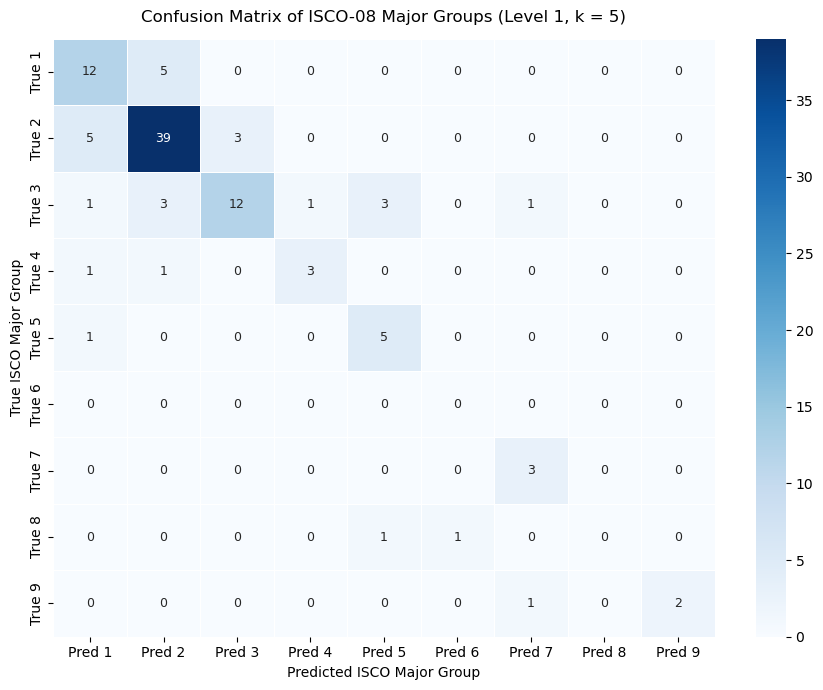

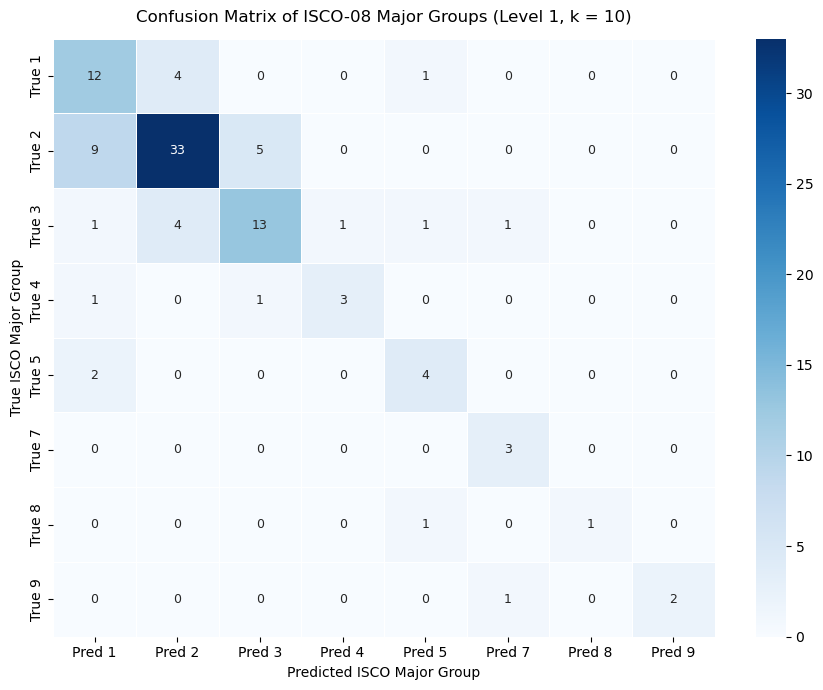

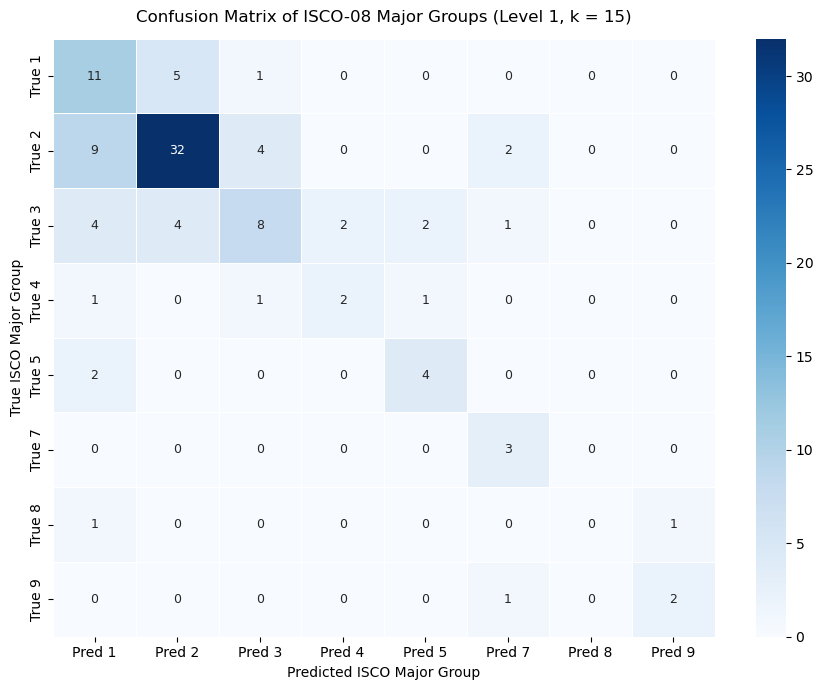

In [18]:
# Ground truthh for Level 1 (Major Groups)
true_lvl1 = ads_df["isco"].astype(str).str[:1]

# Iterating over all selected k-values to generate and save confusion matrices
for k in selected_k_values:
    pred_col = f"prediction_isco_k{k}"
    pred_lvl1 = ads_df[pred_col].astype(str).str[:1]
    
    # Determining all unique labels across true and predicted classes
    lvl_1_labels = sorted(list(set(true_lvl1).union(set(pred_lvl1))))

    # Calculating the confusion matrix
    conf_mat = confusion_matrix(
        true_lvl1,
        pred_lvl1,
        labels=lvl_1_labels,
    )

    # Turning into DataFrame for readable axis labeling
    conf_mat_df = pd.DataFrame(
        conf_mat,
        index=[f"True {label}" for label in lvl_1_labels],
        columns=[f"Pred {label}" for label in lvl_1_labels],
    )

    # Plotting and styling the heatmap
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        conf_mat_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0.5,
        annot_kws={"size": 9}
    )

    plt.title(
        f"Confusion Matrix of ISCO-08 Major Groups (Level 1, k = {k})",
        fontsize=12,
        pad=12
    )
    plt.xlabel("Predicted ISCO Major Group", fontsize=10)
    plt.ylabel("True ISCO Major Group", fontsize=10)
    plt.tight_layout()
    plt.show()
    plt.close()

### 4.3. Detailed Level 1 Major Group Classification Report

In [19]:
# Mapping ISCO-08 Level 1 major group codes to descriptive titles
major_group_names = {
    "1": "Managers",
    "2": "Professionals",
    "3": "Technicians & Assoc. Prof.",
    "4": "Clerical Support",
    "5": "Services & Sales",
    "6": "Skilled Agricultural",
    "7": "Craft & Related Trades",
    "8": "Plant/Machine Operators",
    "9": "Elementary Occupations"
}

# Ground truth labels for Level 1
true_lvl1 = ads_df["isco"].astype(str).str[:1]

# List to collect all formatted classification report strings
all_class_reports = []
separator = "=" * 80

output_dir = "ICLLM_results"

# Iterating over all selected k-values to compute and format Level 1 classification reports
for k in selected_k_values:
    # Resolving prediction column dynamically
    pred_col = f"prediction_isco_{k}" if f"prediction_isco_{k}" in ads_df.columns else f"prediction_isco_k{k}"
    pred_lvl1 = ads_df[pred_col].astype(str).str[:1]
    
    # Determining all unique labels across ground truth and predictions for current k
    lvl_1_labels = sorted(list(set(true_lvl1).union(set(pred_lvl1))))

    # Calculating classification metrics dictionary
    report_dict = classification_report(
        true_lvl1, 
        pred_lvl1, 
        labels=lvl_1_labels,
        output_dict=True, 
        zero_division=0
    )

    # Converting dictionary to DataFrame and filtering on major groups
    report_df = pd.DataFrame(report_dict).T
    report_df = report_df.loc[lvl_1_labels]
    report_df["Class Name"] = [major_group_names.get(code, "Unknown") for code in lvl_1_labels]

    # Reordering, rounding, and formatting columns
    report_df = report_df[["Class Name", "precision", "recall", "f1-score", "support"]]
    report_df["support"] = report_df["support"].astype(int)
    report_df = report_df.round({"precision": 3, "recall": 3, "f1-score": 3})
    report_df.index.name = "Major Group"

    # Building formatted string block for current k
    k_report_text = (
        f"{separator}\n"
        f"       ISCO-08 MAJOR GROUPS CLASSIFICATION REPORT (Level 1, k = {k})\n"
        f"{separator}\n"
        f"{report_df.to_string()}\n"
        f"{separator}\n\n"
    )
    
    all_class_reports.append(k_report_text)
    
    # Printing individual table to terminal/notebook
    print(k_report_text)

       ISCO-08 MAJOR GROUPS CLASSIFICATION REPORT (Level 1, k = 5)
                             Class Name  precision  recall  f1-score  support
Major Group                                                                  
1                              Managers      0.600   0.706     0.649       17
2                         Professionals      0.812   0.830     0.821       47
3            Technicians & Assoc. Prof.      0.800   0.571     0.667       21
4                      Clerical Support      0.750   0.600     0.667        5
5                      Services & Sales      0.556   0.833     0.667        6
6                  Skilled Agricultural      0.000   0.000     0.000        0
7                Craft & Related Trades      0.600   1.000     0.750        3
8               Plant/Machine Operators      0.000   0.000     0.000        2
9                Elementary Occupations      1.000   0.667     0.800        3


       ISCO-08 MAJOR GROUPS CLASSIFICATION REPORT (Level 1, k = 10)
     